# Lecture 7. Word Embeddings and Document Embeddings

# Setup

In [2]:
import warnings; warnings.simplefilter('ignore')
# set this to your working directory
%matplotlib inline
import pandas as pd
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df=df.reset_index(drop=True)
df = df.assign(author_id=(df['authorship']).astype('category').cat.codes)
df = df[pd.notnull(df['authorship'])] # drop cases without an author
import numpy as np
vocab = pd.read_pickle('vec-3grams-1.pkl')
from IPython.display import SVG
from keras.utils import model_to_dot

In [3]:
vocab

CountVectorizer(max_df=0.9, max_features=1000, min_df=0.01, ngram_range=(1, 3),
                stop_words='english')

In [4]:
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,year,log_cite_count,author_id
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,2003,7.981392,2
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,2003,4.762174,9
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,2005,10.058952,4
3,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,2005,4.430817,3
4,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,2005,8.349957,3


# Word2Vec in gensim

In [5]:
# word2vec requires sentences as input
from nltk import sent_tokenize
from string import punctuation
translator = str.maketrans('','',punctuation) 
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('english')

def normalize_text(doc):
    "Input doc and return clean list of tokens"
    doc = doc.replace('\r', ' ').replace('\n', ' ')
    lower = doc.lower() # all lower case
    nopunc = lower.translate(translator) # remove punctuation
    words = nopunc.split() # split into tokens
    nostop = [w for w in words if w not in stoplist] # remove stopwords
    no_numbers = [w if not w.isdigit() else '#' for w in nostop] # normalize numbers
    stemmed = [stemmer.stem(w) for w in no_numbers] # stem each word
    return stemmed

def get_sentences(doc):
    sent=[]
    for raw in sent_tokenize(doc):
        raw2 = normalize_text(raw)
        sent.append(raw2)
    return sent

sentences = []
for doc in df['opinion_text']:
    sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

# train the model
num_words= 300
from gensim.models import Word2Vec
w2v = Word2Vec(sentences,  # list of tokenized sentences
               workers = 8, # Number of threads to run in parallel
               vector_size=num_words,  # Word vector dimensionality     
               min_count =  25, # Minimum word count  
               window = 5, # Context window size      
               sample = 1e-3, # Downsample setting for frequent words
               )

# done training, so delete context vectors
w2v.init_sims(replace=True)

w2v.save('w2v-vectors.pkl')

w2v.wv['judg'] # vector for "judge"

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


array([-3.15211341e-02,  6.11650422e-02,  5.66159263e-02,  9.60324518e-03,
        7.65389502e-02, -1.27487127e-02, -8.60690475e-02, -1.14689104e-01,
       -1.38974665e-02, -4.98209819e-02,  1.36764064e-01, -2.50494182e-02,
        3.62972505e-02, -8.75733346e-02,  2.43174974e-02, -5.73980398e-02,
        3.86775136e-02,  2.87985019e-02, -2.67128814e-02,  7.54089206e-02,
        5.20633273e-02, -2.62950826e-02,  6.92739412e-02, -2.45776698e-02,
       -3.11522894e-02,  5.75079732e-02, -2.76443958e-02,  1.36241633e-02,
        7.55399512e-03,  7.93407187e-02,  1.15069717e-01,  2.41296925e-02,
       -3.38435248e-02, -1.04355533e-02,  1.65308900e-02,  6.37089238e-02,
        4.06692028e-02,  1.63621157e-02, -3.67739983e-02,  3.07972953e-02,
        6.34183884e-02, -1.68172549e-02,  3.64280585e-03, -3.37418430e-02,
        4.10414679e-04, -7.09818453e-02,  1.10206060e-01, -4.77815326e-03,
       -4.05989587e-02,  1.64037608e-02,  6.00895658e-02, -5.43579012e-02,
       -7.05210119e-02, -

In [6]:
w2v.wv.similarity('judg','juri') # similarity 

np.float32(0.5230874)

In [7]:
w2v.wv.most_similar('judg') # most similar words

[('bench', 0.6346781253814697),
 ('court', 0.5347163677215576),
 ('juri', 0.5230873227119446),
 ('factfind', 0.5051027536392212),
 ('panel', 0.4918588697910309),
 ('speedi', 0.48902150988578796),
 ('erron', 0.4848630130290985),
 ('magistr', 0.4811479151248932),
 ('imparti', 0.4751622974872589),
 ('prosecutor', 0.4638526737689972)]

In [8]:
# analogies: judge is to man as __ is to woman
w2v.wv.most_similar(positive=['judg','man'],
                 negative=['woman'])

[('bench', 0.578841507434845),
 ('magistr', 0.5296159386634827),
 ('panel', 0.4834066927433014),
 ('sit', 0.45758184790611267),
 ('prosecutor', 0.452346533536911),
 ('unanim', 0.44763538241386414),
 ('juri', 0.43097734451293945),
 ('imparti', 0.42911186814308167),
 ('oath', 0.42843955755233765),
 ('court', 0.4282413125038147)]

In [9]:
# Word2Vec: K-Means Clusters
from sklearn.cluster import KMeans
kmw = KMeans(n_clusters=50)
kmw.fit(w2v.wv.vectors)

judge_clust = kmw.labels_[w2v.wv.key_to_index['judg']]
for i, cluster in enumerate(kmw.labels_):
    if cluster == judge_clust and i<=100:
        print(w2v.wv.index_to_key[i])

court
case
district
appeal
question
issu
decis
judgment
brief
trial
applic
review
proceed
circuit
judg
consid
present


# Pre-trained vectors

In [10]:
import spacy
en = spacy.load('en_core_web_sm')
apple = en('apple') 
apple.vector # vector for 'apple'

array([-1.1838133 , -0.8882773 , -0.29408097, -0.59344876,  0.16648422,
       -0.53846365,  0.96148324,  0.216802  , -0.4790685 , -0.27562743,
        0.29058665, -1.049209  , -0.37911066,  0.5312755 ,  0.47206905,
        1.4448833 , -0.8657664 , -0.47400755,  0.98587227, -0.19452083,
       -0.43302864,  0.7619376 , -0.41693196, -0.37797722,  1.3568695 ,
        0.03237271,  1.0276382 ,  0.40241203, -0.73181367,  1.3942685 ,
       -0.38214552,  0.16122654,  0.01030424, -0.23572314, -0.20571312,
       -0.7032237 , -0.22249547,  0.65576416, -0.00793771, -0.18970338,
       -0.4086491 , -0.01591997, -0.20140037,  0.35885602,  0.28791487,
       -0.42096803, -0.22308233, -0.74895513,  0.12641451, -0.5474181 ,
        0.05564304, -0.3097041 , -0.11853766, -0.20757279,  1.0038178 ,
        0.03209786,  1.2394714 ,  0.12958106, -0.22994503,  0.12284425,
       -0.7941426 , -0.30465376, -0.05707061, -0.6131594 , -0.0583915 ,
        0.56547695,  0.37080353,  0.13290007, -0.22842097, -0.30

In [11]:
apple.similarity(apple)

1.0

In [12]:
orange = en('orange')
apple.similarity(orange)

0.4297249913215637

In [13]:
import spacy
# !python -m spacy download de_core_news_sm
de = spacy.load('de_core_news_sm')
apfel = de('apfel')
orange = de('orange')
apfel.similarity(orange)

0.023909490555524826

In [14]:
# show the vectors
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, verbose=1, perplexity=50, n_iter=300)

w2v = Word2Vec(min_count=1)
w2v.build_vocab(sentences)  # prepare the model vocabulary
w2v.train(sentences, total_examples=w2v.corpus_count, epochs=w2v.epochs)

df3 = pd.DataFrame(list(w2v.wv.key_to_index.items()),
                  columns=['word', 'word_index']).sort_values('word_index')[:num_words]

for i in range(3):
    if i > 0:
        w2v.train(sentences, total_examples=w2v.corpus_count, epochs=1)
    
    word_vectors = model.layers[0].get_weights()[0]
    wv_tsne = tsne.fit_transform(word_vectors)

    df3['x'] = wv_tsne[:,0]
    df3['y'] = wv_tsne[:,1]
    plot = sns.relplot( data=df3, x="x", y="y", s=0, height=8.27, aspect=11.7/8.27)

    for row in df3.itertuples():
        ax = plot.axes[0, 0]
        ax.text(row.x, row.y, row.word, horizontalalignment='left')
    plt.show()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


NameError: name 'model' is not defined

# GloVe

In [15]:
#!pip install glove-python-binary 
#!pip install glove_python for other versions

import itertools
from glove import Corpus, Glove

corpus = Corpus()
corpus.fit(sentences, window=10)
glove = Glove(no_components=100, learning_rate=0.05)

ModuleNotFoundError: No module named 'glove'

In [16]:
glove.fit(corpus.matrix, epochs=30, no_threads=4, verbose=True)
glove.add_dictionary(corpus.dictionary)

NameError: name 'glove' is not defined

In [17]:
glove.word_vectors[glove.dictionary['judg']]

NameError: name 'glove' is not defined

In [53]:
glove.most_similar('judg')

[('magistr', 0.8493579733770538),
 ('dawson', 0.7547538125927822),
 ('couvillion', 0.7061658918095726),
 ('sit', 0.655695506428154)]


# Word Mover Distance

In [62]:
#!pip install pyemd

In [18]:
import spacy 

nlp = spacy.load('en_core_web_sm')

doc1 = nlp("Politician speaks to the media in Illinois.")
doc2 = nlp("The president greets the press in Chicago.")


w2v.wv.wmdistance(doc1, doc1)

inf

# **Document Embeddings**

In [19]:
###
# Setup
###
import numpy as np
import pandas as pd
df1 = pd.read_csv('death-penalty-cases.csv')

import spacy
nlp = spacy.load('en_core_web_sm')

# word2vec requires sentences as input
sentences = []
for doc in df1['snippet']:
    sents = [sent for sent in nlp(doc).sents]
    sentences += sents
#     sentences += get_sentences(doc)
from random import shuffle
shuffle(sentences) # stream in sentences in random order

In [20]:
df1

,court_id,author_id,state,year,dateFiled,citeCount,snippet
0,nj,NaN,NJ,1965,1965-09-14T00:00:00Z,8,N.J. ( )\n A. d \nIN RE WAIVER OF DEATH PE...
1,fla,4019.0,FL,1973,1973-07-26T00:00:00Z,552,"whether the death penalty is, per se, unconsti..."
2,texcrimapp,5765.0,TX,1975,1975-04-16T00:00:00Z,143,# ;s contention that the assessment of the dea...
3,nm,NaN,NM,2009,2009-11-30T00:00:00Z,0,. d ( )\n -NMSC- \nIN THE MATTER OF DEATH PE...
4,texcrimapp,5758.0,TX,1944,1944-12-20T00:00:00Z,56,assume the district attorney orally waived the...
...,...,...,...,...,...,...,...
32562,ohioctapp,8055.0,OH,2017,2017-07-20T00:00:00Z,0,of two counts of aggravated murder with deat...
32563,cal,NaN,CA,2017,2017-07-20T00:00:00Z,0,his general views about the death penalty as ...
32564,neb,NaN,NE,2017,2017-07-21T00:00:00Z,0,"been subject to the death\npenalty, because Ne..."
32565,ohio,5374.0,OH,2017,2017-07-25T00:00:00Z,0,that Indiana law permits imposition of the de...


**Average word2vec Embeddings**

In [21]:
###
# Make document vectors by averaging word embeddings in a document
##

# Continuous bag-of-words representation
from gensim.models import Word2Vec
w2v = Word2Vec.load('w2v-vectors.pkl')

sentvecs = []
for sentence in sentences:
    vecs = [w2v.wv[w.text] for w in sentence if w.text in w2v.wv]
    if len(vecs)== 0:
        sentvecs.append(np.nan)
        continue
    sentvec = np.mean(vecs,axis=0)
    sentvecs.append(sentvec.reshape(1,-1))
sentvecs[0][0][:30]

array([ 0.04937275,  0.06789184,  0.07136425, -0.06179538, -0.08334143,
       -0.03274641,  0.01905169,  0.00694564, -0.06071514, -0.01138649,
        0.01805524,  0.0796415 , -0.01092799, -0.00016061, -0.0220717 ,
       -0.11045483,  0.02315776,  0.02724979, -0.03752581,  0.00529954,
        0.04841557, -0.05234411,  0.00740368,  0.01750804,  0.00795831,
       -0.01218953, -0.0339187 , -0.03264335, -0.05909996, -0.00576811],
      dtype=float32)

In [22]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(sentvecs[0],
                  sentvecs[1])[0][0]

np.float32(-0.1507464)

**Doc2Vec**

In [23]:
###
# Doc2Vec
###

from nltk import word_tokenize
docs = []

for i, row in df1.iterrows():
    docs += [word_tokenize(row['snippet'])]
shuffle(docs)

In [24]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
doc_iterator = [TaggedDocument(doc, [i]) for i, doc in enumerate(docs)]
d2v = Doc2Vec(doc_iterator,
                min_count=10, # minimum word count
                window=10,    # window size
                vector_size=100, # size of document vector
                sample=1e-4, 
                negative=5, 
                workers=4, # threads
                #dbow_words = 1 # uncomment to get word vectors too
                max_vocab_size=1000) # max vocab size

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [25]:
d2v.save('d2v-vectors.pkl')

In [26]:
D = d2v.docvecs.vectors
D.shape

(32567, 100)

In [27]:
D

array([[-0.04444308,  0.00201711, -0.01125486, ..., -0.01189954,
         0.02957585,  0.05116292],
       [-0.03512027,  0.00769421,  0.01388285, ..., -0.04103271,
         0.00207271,  0.01164516],
       [-0.07970429, -0.02657576,  0.04897419, ..., -0.06138295,
         0.01460361, -0.01077101],
       ...,
       [-0.0018463 , -0.00481052, -0.00399755, ...,  0.01904709,
         0.03341179, -0.0001125 ],
       [-0.03122625,  0.01545517,  0.02520391, ..., -0.02903534,
        -0.01039479,  0.01642493],
       [-0.02908602,  0.02074152,  0.00544178, ..., -0.02863265,
         0.01880906,  0.0207292 ]], shape=(32567, 100), dtype=float32)

In [28]:
# infer vectors for new documents
a = d2v.infer_vector(['the judge on the court'])

b = d2v.infer_vector(['the jury and the judge'])

c = d2v.infer_vector(['cats hunt mice'])

In [29]:
a.shape, b.shape

((100,), (100,))

In [30]:
print(cosine_similarity(np.expand_dims(a, axis=0), np.expand_dims(b, axis=0)))
print(cosine_similarity(np.expand_dims(a, axis=0), np.expand_dims(c, axis=0)))

[[-0.19588965]]
[[-0.04572473]]


In [31]:
# get all pair-wise document similarities
pairwise_sims = cosine_similarity(D)

In [32]:
pairwise_sims[:3,:3]

array([[1.        , 0.8222366 , 0.77076674],
       [0.8222366 , 0.99999994, 0.79481584],
       [0.77076674, 0.79481584, 0.9999999 ]], dtype=float32)

In [33]:
# Document clusters
from sklearn.cluster import KMeans

# create 50 clusters of similar documents
num_clusters = 50
kmw = KMeans(n_clusters=num_clusters)
kmw.fit(D)

KMeans(n_clusters=50)

In [34]:
# Documents from an example cluster
for i, doc in enumerate(docs):
    if kmw.labels_[i] == 25:
        print(' '.join(doc[:9]))
    if i == 1000:
        break

judgments under the Antiterrorism and Effective Death Penalty Act
charged Sanders with murder and sought the death penalty
( procedure for imposition of the death penalty )
commission of a kidnapping and provided for the death
jury & # ; s decision as to whether
to affirm or reverse a judgment except in death
felonies where the prosecution does not seek the death
Ed . d ( ) ( granting habeas relief
say my statement is you should give me the
requirement was limited to pre-Torrence [ ] death penalty
the circuit court , so far as it imposed
appeal for want of prosecution — effectively , a
and fear . The jury might have assessed the
writs , and an oral argument in a death
the shootings involved police officers , the death penalty
next motion to disqualify may be brought in a
accepted a plea offer in order to avoid the
capital murder . The State did not seek the
p . . ) In Easley , the court
the State had asked the jury to recommend the
were crying as death penalty verdict was announced wou

In [111]:
# t-SNE for visualization
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, verbose=1, perplexity=50, n_iter=300)
# d2v_tsne = tsne.fit_transform(D)

In [35]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3,svd_solver='randomized')
Xpca = pca.fit_transform(D)
pca.explained_variance_ratio_

array([0.47618586, 0.06537274, 0.05220378], dtype=float32)

In [113]:
#vdf = pd.DataFrame(Xpca,
#                  columns=['x-tsne', 'y-tsne'])
#vdf['cluster'] = kmw.labels_

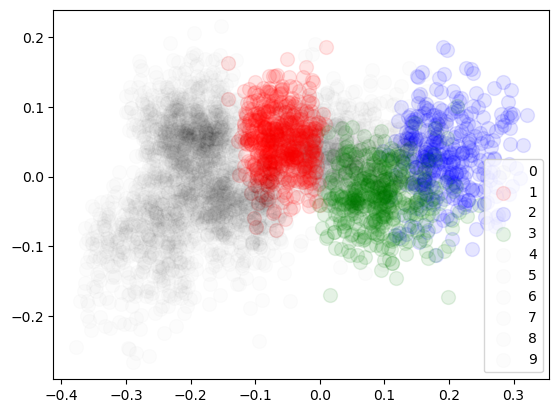

In [36]:
#%% PCA Viz
import matplotlib.pyplot as plt

#plt.scatter(Xpca[:,0],Xpca[:,1], alpha=.1)

cdict = {1: 'red', 2: 'blue', 3: 'green'}
fig, ax = plt.subplots()
#for g, label in cdict.items():
for g in np.unique(kmw.labels_):
    ix = np.where(kmw.labels_ == g)
    #ix = np.where(kmw == g)
    #    ax.scatter(scatter_x[ix], scatter_y[ix], c = cdict[g], label = g, s = 100)
    if g in cdict:
        # use color from cdict
        color = cdict[g]
        ax.scatter(Xpca[:,0][ix], Xpca[:,1][ix], c = color, label = g, s = 100, alpha=0.1)
    else:
        if g < 10:
            color = "black"
            ax.scatter(Xpca[:,0][ix], Xpca[:,1][ix], c = color, label = g, s = 100, alpha=0.01)
    

        
ax.legend()
plt.show()

In [37]:
# sample 100 texts to show different document embeddings techniques

texts = df1["snippet"][:100]
text = texts[0]
text, texts

('N.J.   ( )\n  A. d  \nIN RE WAIVER OF DEATH PENALTY.\nThe Supreme Court of New Jersey.\nSeptember & ; and County Court Judges\n\nRe: Waiver of the Death Penalty\n*  The Supreme Court is concerned by the excessive& ;cases where the prosecutor is not seeking the death penalty. It is cognizant of the fact that this situation& ;Although the prosecutor had a right to waive the death penalty and so inform the jury, the jury nevertheless& ;would assume, as did the prosecutor, that the death penalty would not be returned as it was not asked for',
 0     N.J.   ( )\n  A. d  \nIN RE WAIVER OF DEATH PE...
 1     whether the death penalty is, per se, unconsti...
 2     # ;s contention that the assessment of the dea...
 3     . d   ( )\n -NMSC- \nIN THE MATTER OF DEATH PE...
 4     assume the district attorney orally waived the...
                             ...                        
 95    guilty as to all defendants and imposing the d...
 96     present death penalty statutes, juries could .

**Other types of Document Embeddings**

In [38]:
# spacy embeddings (= averaged gloVe embeddings)

import spacy
nlp = spacy.load('en_core_web_sm')

doc = nlp(text)
doc.vector

array([-0.07381222, -0.41067973,  0.24918824,  0.08832427, -0.07718101,
       -0.14574058,  0.14925523,  0.05309219,  0.08645238,  0.08308491,
       -0.09708435,  0.13183391, -0.07744556,  0.03050521,  0.04236082,
        0.05468771, -0.04923629,  0.22025606,  0.20358358, -0.20787044,
        0.15564153,  0.29487655,  0.08843628, -0.11228389,  0.24737827,
        0.11567172,  0.0822051 , -0.17482571,  0.16438788,  0.41385794,
       -0.06660616, -0.01264722,  0.01867562, -0.02417802, -0.08548661,
       -0.1423948 ,  0.12821744,  0.21655631, -0.18357606,  0.02823507,
        0.01703999,  0.17224307,  0.11883076, -0.04907822,  0.21272297,
        0.15662304, -0.0991443 ,  0.01840533,  0.13207686,  0.10207938,
       -0.11846993,  0.18341666, -0.09164458, -0.03193133, -0.03133669,
       -0.19456694,  0.00050494, -0.03162231,  0.15215786, -0.17104633,
       -0.21409532,  0.00161925,  0.03099646, -0.2517169 , -0.0491817 ,
        0.02542091,  0.25066432, -0.08395954, -0.11000192, -0.28

**Uinversal Sentence Encoder**

In [40]:
# universal sentence encoder
!pip install --upgrade tensorflow-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow-hub]


In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

import tensorflow_hub as hub
import numpy as np

module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(module_url)
print ("module %s loaded" % module_url)
def embed(input):
    return model(input)

embeddings = embed([text])

with tf.Session() as session:
    session.run([tf.global_variables_initializer(), tf.tables_initializer()])
    text_encoded = session.run(embeddings)



module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


I0000 00:00:1781270024.857925  290694 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [86]:
text_encoded

array([[-5.75881787e-02, -4.48678993e-02, -5.97575605e-02,
        -9.60366335e-03,  4.87336107e-02, -7.14330003e-02,
         5.63876238e-03, -4.17736471e-02,  6.94411173e-02,
        -7.18879700e-02,  4.38294373e-02,  4.96255197e-02,
         2.92646624e-02,  5.06394245e-02,  5.02831191e-02,
        -5.43750636e-02,  1.20516934e-05,  3.34072635e-02,
        -2.29961034e-02,  5.17977625e-02,  1.33965574e-02,
         2.34781709e-02,  6.57833889e-02, -2.41349824e-02,
        -5.89741282e-02,  4.48849648e-02,  8.91339593e-03,
        -1.31372558e-02, -5.10082208e-02,  8.32207967e-03,
         3.43775637e-02, -6.50016367e-02,  3.18927504e-02,
        -5.33328839e-02, -6.16215952e-02, -6.11270331e-02,
        -4.20963466e-02,  1.39375580e-02,  6.44143624e-03,
         6.65995479e-02, -3.60511541e-02, -1.41065773e-02,
        -7.03564053e-03, -4.17812392e-02, -4.14931811e-02,
         5.47353178e-02,  2.42106803e-02, -6.66408911e-02,
        -3.75429988e-02, -5.52068166e-02, -5.62858656e-0

**SBERT**

In [ ]:
!pip install sentence-transformers

In [88]:
from sentence_transformers import SentenceTransformer
model = "bert-base-nli-mean-tokens"
embedder = SentenceTransformer(model)
text_encoded = embedder.encode([text])

In [89]:
text_encoded

array([[-4.94830877e-01, -3.07748497e-01,  2.38643706e-01,
        -1.12242088e-01,  3.68263185e-01, -2.13435516e-01,
         8.10863554e-01, -2.53932953e-01,  8.49518254e-02,
         4.34113666e-02, -5.31976391e-03,  4.72682863e-01,
         9.99898016e-02,  4.15400296e-01, -1.31251180e+00,
         4.92496580e-01,  1.40618965e-01, -3.23016405e-01,
         1.41713113e-01, -3.53501767e-01,  4.34755124e-02,
        -7.69813284e-02,  2.29930565e-01,  5.27145088e-01,
         9.18621957e-01,  6.17869377e-01, -5.80663979e-01,
         2.21835390e-01, -7.82553732e-01,  5.84526539e-01,
        -1.58552885e-01,  2.56739974e-01, -1.15312052e+00,
         5.24774147e-03,  6.55010790e-02,  5.42442918e-01,
         1.94232747e-01, -1.94006234e-01,  2.46752918e-01,
         1.75805941e-01, -6.84098899e-01,  1.05391644e-01,
        -3.26745480e-01, -2.70014167e-01, -1.21031687e-01,
        -4.18343127e-01,  1.40245140e+00,  4.35338885e-01,
         9.15403128e-01, -1.82648510e-01,  3.20812970e-0